## Universidad Autónoma de Aguascalientes
## Departamento: Ciencias de la Computación
## Carrera: Ingeniería en Computación Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero-Junio del 2026

---

# PRÁCTICA: Análisis de Sentimientos con Redes Neuronales Convolucionales 1D (CNN-1D)

## Introducción

El **Análisis de Sentimientos** (o *Sentiment Analysis*) es una tarea de Procesamiento de Lenguaje Natural (NLP) que consiste en identificar y extraer información subjetiva de texto. En este caso, determinaremos si una crítica de cine tiene un sentimiento **positivo (1)** o **negativo (0)**.

### ¿Por qué CNN-1D para texto?

Aunque las CNNs son más conocidas por su aplicación en imágenes (2D), las **CNNs 1D** son una arquitectura muy eficiente para datos secuenciales como texto. Funcionan aplicando filtros convolucionales a lo largo de la secuencia de palabras (en lugar de sobre píxeles), capturando **patrones locales de n-gramas** (por ejemplo, pares o tríos de palabras que aparecen juntos) que son informativos para la clasificación.

Ventajas sobre RNNs/LSTMs:
- Entrenamiento más rápido (operaciones paralelizables)
- Captura eficientemente relaciones locales entre palabras
- Excelente rendimiento en tareas de clasificación de texto

### Dataset: Críticas de Cine (`movie_data.csv`)

Utilizaremos un dataset propio de reseñas de películas en formato CSV con dos columnas:
- `review`    : texto de la crítica de cine
- `sentiment` : etiqueta binaria (`1` = positivo, `0` = negativo)

## Paso 1: Importar las librerías necesarias

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.75'

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, MaxPooling1D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("TensorFlow versión:", tf.__version__)
print("Keras versión     :", keras.__version__)
print("NumPy versión     :", np.__version__)

I0000 00:00:1778545378.739153   24227 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778545379.072692   24227 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778545381.263438   24227 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow versión: 2.21.0
Keras versión     : 3.14.1
NumPy versión     : 2.4.4


## Paso 2: Verificación y configuración de GPU (CUDA)

TensorFlow detecta automáticamente las GPUs disponibles mediante CUDA. Si hay al menos una GPU compatible, el entrenamiento se ejecutará en ella; de lo contrario se usará la CPU.

- `tf.config.list_physical_devices('GPU')` lista todas las GPUs físicas visibles para TensorFlow.
- `set_memory_growth(True)` hace que TensorFlow asigne memoria de GPU de forma dinámica y progresiva, en lugar de reservar toda la VRAM al iniciar, lo cual es especialmente útil en entornos compartidos.
- `tf.device(DEVICE)` se usará más adelante para asegurar que la construcción y el entrenamiento del modelo ocurran en el dispositivo correcto.

In [2]:
# ============================================================
#  Detección de GPU / CUDA
# ============================================================
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Activamos crecimiento de memoria dinámico en cada GPU detectada
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        print(f"✅  CUDA disponible — {len(gpus)} GPU(s) detectada(s):")
        for i, gpu in enumerate(gpus):
            details = tf.config.experimental.get_device_details(gpu)
            nombre  = details.get('device_name', 'Nombre no disponible')
            print(f"     GPU {i}: {nombre}  ({gpu.name})")

        DEVICE = '/GPU:0'   # Usamos la primera GPU disponible

    except RuntimeError as e:
        # set_memory_growth debe llamarse antes de inicializar las GPUs
        print(f"⚠️  Error al configurar GPU: {e}")
        DEVICE = '/CPU:0'
else:
    print("⚠️  No se detectó ninguna GPU compatible con CUDA.")
    print("    El entrenamiento se ejecutará en CPU.")
    DEVICE = '/CPU:0'

print(f"\n→ Dispositivo de cómputo seleccionado : {DEVICE}")
print(f"  CUDA compilado en TensorFlow        : {tf.test.is_built_with_cuda()}")

✅  CUDA disponible — 1 GPU(s) detectada(s):
     GPU 0: NVIDIA GeForce RTX 5060 Laptop GPU  (/physical_device:GPU:0)

→ Dispositivo de cómputo seleccionado : /GPU:0
  CUDA compilado en TensorFlow        : True


W0000 00:00:1778545394.841469   24227 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## Paso 3: Cargar el dataset desde `movie_data.csv`

Cargamos el archivo CSV, inspeccionamos su estructura, limpiamos el texto (eliminando etiquetas HTML y caracteres especiales) y dividimos el dataset en conjuntos de entrenamiento y prueba con una proporción 80/20 estratificada.

In [3]:
# ============================================================
#  Carga del CSV
# ============================================================
df = pd.read_csv('./movie_data.csv')

print("=== Estructura del dataset ===")
print(f"Filas x Columnas : {df.shape}")
print(f"Columnas         : {list(df.columns)}")
print(f"Valores nulos    : {df.isnull().sum().to_dict()}")
print("\nPrimeras 3 filas:")
display(df.head(3))

# ============================================================
#  Limpieza de texto
# ============================================================
def clean_text(text):
    """
    Preprocesamiento básico de una reseña de cine:
      1. Elimina etiquetas HTML  (<br />, <b>, etc.)
      2. Convierte a minúsculas
      3. Elimina caracteres no alfabéticos (conserva espacios)
      4. Colapsa espacios múltiples
    """
    text = re.sub(r'<[^>]+>', ' ', str(text))   # quitar HTML
    text = text.lower()                          # minúsculas
    text = re.sub(r'[^a-z\s]', ' ', text)       # solo letras
    text = re.sub(r'\s+', ' ', text).strip()    # espacios múltiples
    return text

df['review_clean'] = df['review'].apply(clean_text)

print("\n=== Ejemplo de limpieza de texto ===")
print("ORIGINAL :", df['review'].iloc[0][:200])
print("LIMPIO   :", df['review_clean'].iloc[0][:200])

# ============================================================
#  División train / test  (80 / 20, estratificada)
# ============================================================
X = df['review_clean'].values
y = df['sentiment'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\n=== División del dataset ===")
print(f"Entrenamiento : {len(X_train_raw)} muestras")
print(f"Prueba        : {len(X_test_raw)}  muestras")
print(f"\nEntrenamiento — Positivos: {np.sum(y_train==1)} | Negativos: {np.sum(y_train==0)}")
print(f"Prueba        — Positivos: {np.sum(y_test==1)}  | Negativos: {np.sum(y_test==0)}")

=== Estructura del dataset ===
Filas x Columnas : (50000, 2)
Columnas         : ['review', 'sentiment']
Valores nulos    : {'review': 0, 'sentiment': 0}

Primeras 3 filas:


,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0



=== Ejemplo de limpieza de texto ===
ORIGINAL : In 1974, the teenager Martha Moxley (Maggie Grace) moves to the high-class area of Belle Haven, Greenwich, Connecticut. On the Mischief Night, eve of Halloween, she was murdered in the backyard of her
LIMPIO   : in the teenager martha moxley maggie grace moves to the high class area of belle haven greenwich connecticut on the mischief night eve of halloween she was murdered in the backyard of her house and he

=== División del dataset ===
Entrenamiento : 40000 muestras
Prueba        : 10000  muestras

Entrenamiento — Positivos: 20000 | Negativos: 20000
Prueba        — Positivos: 5000  | Negativos: 5000


## Paso 4: Análisis exploratorio de los datos

=== Estadísticas de longitud de reseñas (palabras) ===
  Mínimo       : 6
  Máximo       : 2494
  Media        : 234.2
  Mediana      : 176.0
  Percentil 90 : 457
  Percentil 95 : 598


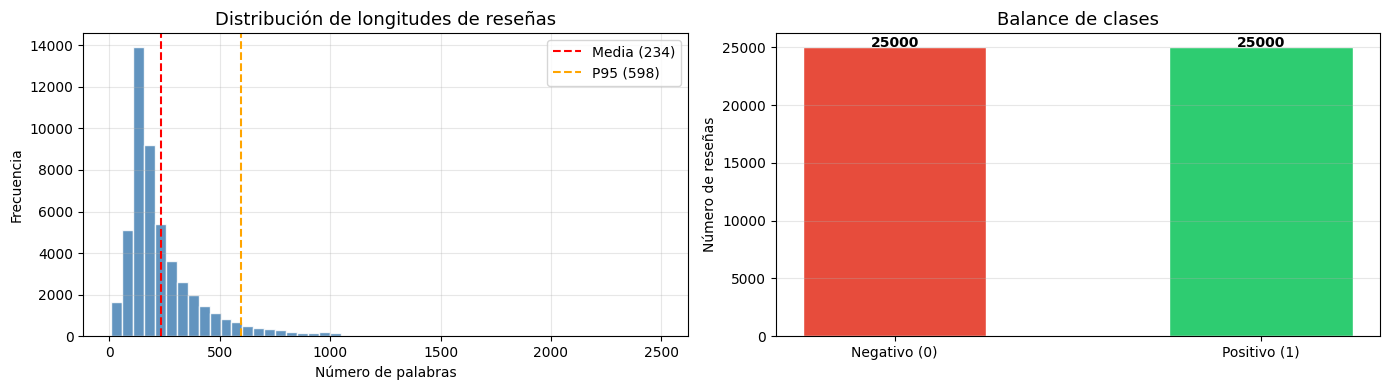

In [4]:
# Longitud de cada reseña en palabras (después de la limpieza)
all_lengths = [len(t.split()) for t in X]

print("=== Estadísticas de longitud de reseñas (palabras) ===")
print(f"  Mínimo       : {np.min(all_lengths)}")
print(f"  Máximo       : {np.max(all_lengths)}")
print(f"  Media        : {np.mean(all_lengths):.1f}")
print(f"  Mediana      : {np.median(all_lengths):.1f}")
print(f"  Percentil 90 : {np.percentile(all_lengths, 90):.0f}")
print(f"  Percentil 95 : {np.percentile(all_lengths, 95):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de longitudes
axes[0].hist(all_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(all_lengths), color='red', linestyle='--',
                label=f'Media ({np.mean(all_lengths):.0f})')
axes[0].axvline(np.percentile(all_lengths, 95), color='orange', linestyle='--',
                label=f'P95 ({np.percentile(all_lengths, 95):.0f})')
axes[0].set_title('Distribución de longitudes de reseñas', fontsize=13)
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Balance de clases
clases  = ['Negativo (0)', 'Positivo (1)']
conteos = [int(np.sum(y == 0)), int(np.sum(y == 1))]
bars = axes[1].bar(clases, conteos, color=['#e74c3c', '#2ecc71'],
                   edgecolor='white', width=0.5)
axes[1].set_title('Balance de clases', fontsize=13)
axes[1].set_ylabel('Número de reseñas')
for bar, v in zip(bars, conteos):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 5,
                 str(v), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Paso 5: Visualización de reseñas reales

Al cargar el dataset desde CSV tenemos acceso directo al texto, por lo que podemos inspeccionar las reseñas sin necesidad de decodificar índices.

In [5]:
pos_idx = np.where(y_train == 1)[0][0]
neg_idx = np.where(y_train == 0)[0][0]

print("=" * 70)
print("EJEMPLO DE RESEÑA POSITIVA (y = 1):")
print("=" * 70)
print(X_train_raw[pos_idx][:600], "...")

print("\n" + "=" * 70)
print("EJEMPLO DE RESEÑA NEGATIVA (y = 0):")
print("=" * 70)
print(X_train_raw[neg_idx][:600], "...")

EJEMPLO DE RESEÑA POSITIVA (y = 1):
i m really getting old am in the midst of watching this year old flick and wonder what my grandchildren will be watching years from now its an old saying but they don t make em like that anymore it s not only the story its the music the acting both by young and old the cast it would seem were born to play their roles young oliver old fagin too many to mention them all the role played by the judge oliver stands before i ve seen in other roles over the years the artful dodger ron moody as fagin mr and mrs bumble the movie not only won oscars but took a few golden globe awards too if you decide t ...

EJEMPLO DE RESEÑA NEGATIVA (y = 0):
i was sooooo excited to see this movie after finally reading the book this week my year old son was looking forward to it too i rented it and snuggled down to enjoy a classic holiday story brought to life on screen boy was i disappointed this movie veered off from the book more times than is forgivable george c scott is 

## Paso 6: Tokenización y Padding

### ¿Qué hace el `Tokenizer` de Keras?

Construye un vocabulario a partir del corpus de entrenamiento, asignando un índice entero único a cada palabra ordenada por frecuencia descendente. Luego convierte cada reseña en una secuencia de esos índices.

**Parámetros clave:**
- `num_words`: conserva solo las `VOCAB_SIZE` palabras más frecuentes; el resto se trata como desconocido.
- `oov_token='<OOV>'`: token especial para palabras fuera del vocabulario en inferencia.

> ⚠️ El `Tokenizer` se ajusta **únicamente con datos de entrenamiento** para evitar *data leakage*. El conjunto de prueba solo se transforma, nunca se usa para aprender el vocabulario.

Después de tokenizar, aplicamos **padding** (`pad_sequences`) para que todas las reseñas tengan la misma longitud `MAX_LEN = 500`, elegida para cubrir el percentil 95 de longitudes del corpus.

In [6]:
# ============================================================
#  HIPERPARÁMETROS DE PREPROCESAMIENTO
# ============================================================
VOCAB_SIZE = 10000   # Top N palabras más frecuentes a retener
MAX_LEN    = 250     # Longitud fija de secuencia (cubre ~P95)

# ============================================================
#  TOKENIZACIÓN — ajuste sobre entrenamiento únicamente
# ============================================================
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>',
    lower=True
)
tokenizer.fit_on_texts(X_train_raw)   # ← solo sobre X_train

print("=== Tokenizer ===")
print(f"Vocabulario total en corpus      : {len(tokenizer.word_index)} palabras")
print(f"Vocabulario utilizado (top N)    : {VOCAB_SIZE} palabras")

# Palabras más frecuentes
top15 = sorted(tokenizer.word_counts.items(), key=lambda x: -x[1])[:15]
print("\nTop 15 palabras más frecuentes:")
for palabra, freq in top15:
    print(f"  '{palabra}': {freq}")

# ============================================================
#  CONVERSIÓN A SECUENCIAS
# ============================================================
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

print("\nEjemplo — primeros 20 tokens de la reseña [0]:")
print(X_train_seq[0][:20])

# ============================================================
#  PADDING / TRUNCAMIENTO
# ============================================================
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print("\n=== Dimensiones finales ===")
print(f"X_train_pad : {X_train_pad.shape}")
print(f"X_test_pad  : {X_test_pad.shape}")
print(f"y_train     : {y_train.shape}")
print(f"y_test      : {y_test.shape}")

=== Tokenizer ===
Vocabulario total en corpus      : 90858 palabras
Vocabulario utilizado (top N)    : 10000 palabras

Top 15 palabras más frecuentes:
  'the': 535065
  'and': 259793
  'a': 258748
  'of': 231931
  'to': 214917
  'is': 169019
  'it': 153090
  'in': 149783
  'i': 140780
  'this': 120727
  'that': 115046
  's': 104170
  'was': 76343
  'as': 73548
  'for': 70294

Ejemplo — primeros 20 tokens de la reseña [0]:
[10, 138, 64, 378, 159, 233, 9, 2, 6513, 5, 150, 11, 288, 159, 482, 3, 580, 48, 59, 1]

=== Dimensiones finales ===
X_train_pad : (40000, 250)
X_test_pad  : (10000, 250)
y_train     : (40000,)
y_test      : (10000,)


## Paso 7: Arquitectura de la CNN-1D

### Componentes clave:

| Capa | Descripción |
|------|-------------|
| **Embedding** | Convierte cada token (entero) en un vector denso de dimensión `EMBED_DIM`. Sus pesos se aprenden durante el entrenamiento. |
| **Conv1D** | Aplica filtros deslizantes sobre ventanas de palabras consecutivas (n-gramas). Detecta patrones locales de sentimiento. |
| **BatchNormalization** | Normaliza las activaciones de cada lote para estabilizar y acelerar el entrenamiento. |
| **MaxPooling1D** | Reduce la dimensión temporal conservando las activaciones más relevantes. |
| **GlobalMaxPooling1D** | Extrae el valor máximo de toda la secuencia por cada filtro, logrando invarianza a la posición. |
| **Dense + Dropout** | Capas de clasificación final. Dropout mitiga el sobreajuste. |
| **Sigmoid** | Salida en (0,1): probabilidad de sentimiento positivo. |

In [7]:
# ============================================================
#  HIPERPARÁMETROS DEL MODELO
# ============================================================
EMBED_DIM     = 128
NUM_FILTERS   = 128
KERNEL_SIZE   = 5
DENSE_UNITS   = 64
DROPOUT_RATE  = 0.5
LEARNING_RATE = 5e-4  # ← Reducido ligeramente para mayor estabilidad

# ============================================================
#  DEFINICIÓN DEL MODELO
# ============================================================
def build_cnn1d_model(vocab_size, max_len, embed_dim, num_filters,
                      kernel_size, dense_units, dropout_rate):
    model = Sequential(name='CNN_1D_Sentiment')

    # vocab_size + 1 para incluir el índice 0 reservado al padding
    model.add(Embedding(input_dim=vocab_size + 1,
                        output_dim=embed_dim,
                        input_length=max_len,
                        name='embedding'))

    # Bloque convolucional 1
    model.add(Conv1D(filters=num_filters, kernel_size=kernel_size,
                     activation='relu', padding='same', name='conv1d_1'))
    model.add(BatchNormalization(name='bn_1'))
    model.add(MaxPooling1D(pool_size=2, name='maxpool_1'))

    # Bloque convolucional 2
    model.add(Conv1D(filters=num_filters * 2, kernel_size=kernel_size,
                     activation='relu', padding='same', name='conv1d_2'))
    model.add(BatchNormalization(name='bn_2'))
    model.add(MaxPooling1D(pool_size=2, name='maxpool_2'))

    # Bloque convolucional 3 — patrones de alto nivel
    model.add(Conv1D(filters=num_filters * 2, kernel_size=kernel_size,
                     activation='relu', padding='same', name='conv1d_3'))
    model.add(BatchNormalization(name='bn_3'))

    # Global max pooling — reduce la secuencia a un vector fijo
    model.add(GlobalMaxPooling1D(name='global_maxpool'))

    # Capas densas de clasificación
    model.add(Dense(dense_units, activation='relu', name='dense_1'))
    model.add(Dropout(dropout_rate, name='dropout_1'))
    model.add(Dense(32, activation='relu', name='dense_2'))
    model.add(Dropout(dropout_rate / 2, name='dropout_2'))

    # Salida binaria
    model.add(Dense(1, activation='sigmoid', name='output'))
    return model


# Construimos y compilamos el modelo en el dispositivo seleccionado (GPU o CPU)
with tf.device(DEVICE):
    model = build_cnn1d_model(
        vocab_size=VOCAB_SIZE, max_len=MAX_LEN,
        embed_dim=EMBED_DIM, num_filters=NUM_FILTERS,
        kernel_size=KERNEL_SIZE, dense_units=DENSE_UNITS,
        dropout_rate=DROPOUT_RATE
    )
    model.compile(
        # ← Agregamos clipnorm=1.0 para evitar la explosión a 'nan'
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

model.summary()

W0000 00:00:1778545426.152473   24227 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778545426.574517   24227 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1778545426.575197   24227 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
/home/memoo/tf-gpu/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_1D_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_maxpool                  │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Paso 8: Entrenamiento del modelo

### Callbacks utilizados:
- **EarlyStopping**: Detiene el entrenamiento si `val_loss` no mejora durante `patience` épocas y restaura los mejores pesos automáticamente.
- **ReduceLROnPlateau**: Reduce la tasa de aprendizaje a la mitad cuando el modelo se estanca en validación, permitiendo una convergencia más fina hacia el mínimo.

In [8]:
BATCH_SIZE = 32
EPOCHS     = 20

early_stop = EarlyStopping(
    monitor='val_loss', patience=4,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-6, verbose=1
)

print(f"Entrenando en dispositivo: {DEVICE}")
print("-" * 50)

history = model.fit(
    X_train_pad, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,          # 20% del training como validación
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nEntrenamiento completado en {len(history.history['loss'])} épocas.")

Entrenando en dispositivo: /GPU:0
--------------------------------------------------
Epoch 1/20


I0000 00:00:1778545434.721455   24459 service.cc:153] XLA service 0x7cb7940082e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778545434.721495   24459 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1778545434.809517   24459 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778545435.624092   24459 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1778545435.727201   24459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5059__.64
W0000 00:00:1778545436.145016   24527 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6492253399 bytes) by rematerialization; only reduced to 9.15GiB (9823387696 bytes), down from 9.15GiB (9823387696 bytes) originally
W0000 00:00:1778545441.545836   

   7/1000 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.5209 - loss: nan     

I0000 00:00:1778545457.721095   24459 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5009 - loss: nan

W0000 00:00:1778545464.272963   24899 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6492253399 bytes) by rematerialization; only reduced to 9.15GiB (9823387696 bytes), down from 9.15GiB (9823387696 bytes) originally
W0000 00:00:1778545468.545283   24900 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.04GiB (6491329828 bytes) by rematerialization; only reduced to 10.09GiB (10834247728 bytes), down from 10.09GiB (10834247728 bytes) originally
W0000 00:00:1778545474.396353   24909 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6492963646 bytes) by rematerialization; only reduced to 18.15GiB (19489898544 bytes), down from 18.15GiB (19489898544 bytes) originally
E0000 00:00:1778545474.517420   24461 gpu_cudamallocasync_allocator.cc:359] gpu_async_0 cuMemAllocAsync failed to allocate 19485803024 bytes: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
 Reported by CUDA: Free memory/Total memory: 1332740096/8546484224
E

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - accuracy: 0.5002 - loss: nan - val_accuracy: 0.4989 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5003 - loss: nan - val_accuracy: 0.4989 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 3/20
 998/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4969 - loss: nan
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5003 - loss: nan - val_accuracy: 0.4989 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5003 - loss: nan - val_accuracy: 0.4989 - val_loss: nan - learning_rate: 2.5000e-04
Epoch 5/20
 992/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4964 - loss: nan
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5003 - loss: nan - val_accuracy: 

## Paso 9: Visualización del historial de entrenamiento

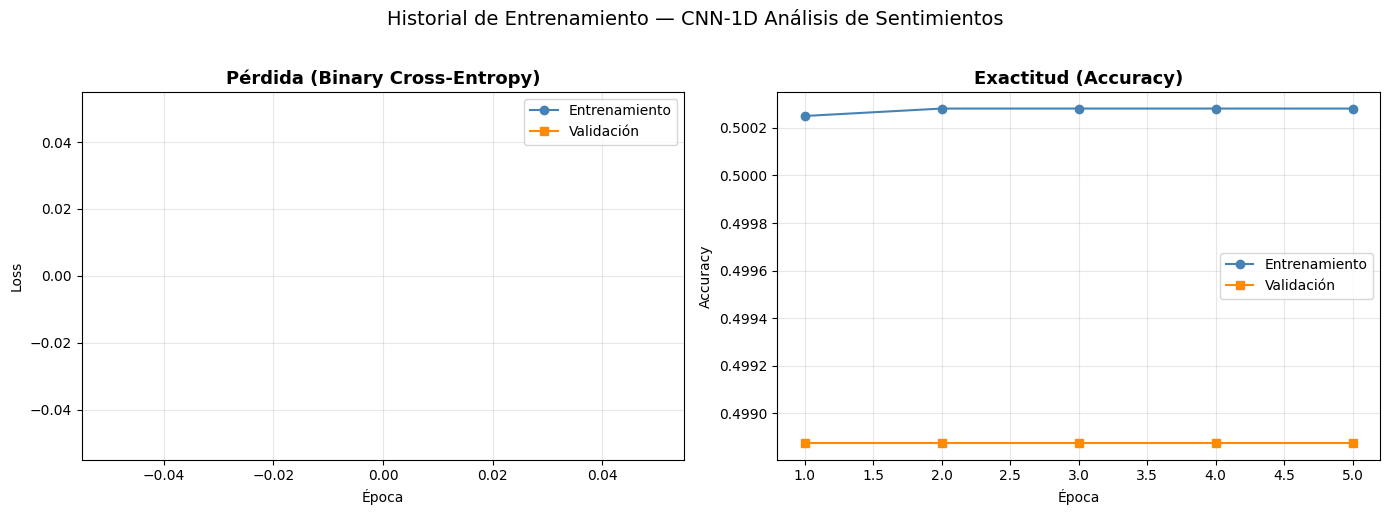

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history.history['loss']) + 1)

# Pérdida
axes[0].plot(ep, history.history['loss'],     'o-', color='steelblue',  label='Entrenamiento')
axes[0].plot(ep, history.history['val_loss'], 's-', color='darkorange', label='Validación')
axes[0].set_title('Pérdida (Binary Cross-Entropy)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exactitud
axes[1].plot(ep, history.history['accuracy'],     'o-', color='steelblue',  label='Entrenamiento')
axes[1].plot(ep, history.history['val_accuracy'], 's-', color='darkorange', label='Validación')
axes[1].set_title('Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Historial de Entrenamiento — CNN-1D Análisis de Sentimientos',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Paso 10: Evaluación en el conjunto de prueba

In [10]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, batch_size=32, verbose=0)
print(f"{'='*45}")
print(f"  Pérdida en test   : {test_loss:.4f}")
print(f"  Exactitud en test : {test_acc * 100:.2f}%")
print(f"{'='*45}")

y_pred_prob = model.predict(X_test_pad, batch_size=32, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred,
                             target_names=['Negativo (0)', 'Positivo (1)']))

W0000 00:00:1778545528.778123   25511 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6493167626 bytes) by rematerialization; only reduced to 8.64GiB (9275080752 bytes), down from 8.64GiB (9275080752 bytes) originally
W0000 00:00:1778545532.415485   25508 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6493173028 bytes) by rematerialization; only reduced to 9.08GiB (9745973296 bytes), down from 9.08GiB (9745973296 bytes) originally
W0000 00:00:1778545537.159849   25510 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6493834046 bytes) by rematerialization; only reduced to 17.14GiB (18402648112 bytes), down from 17.14GiB (18402648112 bytes) originally
E0000 00:00:1778545537.306460   24461 gpu_cudamallocasync_allocator.cc:359] gpu_async_0 cuMemAllocAsync failed to allocate 18400600592 bytes: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
 Reported by CUDA: Free memory/Total memory: 1332740096/8546484224
E0000

  Pérdida en test   : nan
  Exactitud en test : 50.00%

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

Negativo (0)       0.50      1.00      0.67      5000
Positivo (1)       0.00      0.00      0.00      5000

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



/home/memoo/tf-gpu/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/memoo/tf-gpu/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/memoo/tf-gpu/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Paso 11: Matriz de Confusión y Curva ROC

Verdaderos Negativos (TN): 5000
Falsos Positivos     (FP): 0
Falsos Negativos     (FN): 5000
Verdaderos Positivos (TP): 0


ValueError: Input contains NaN.

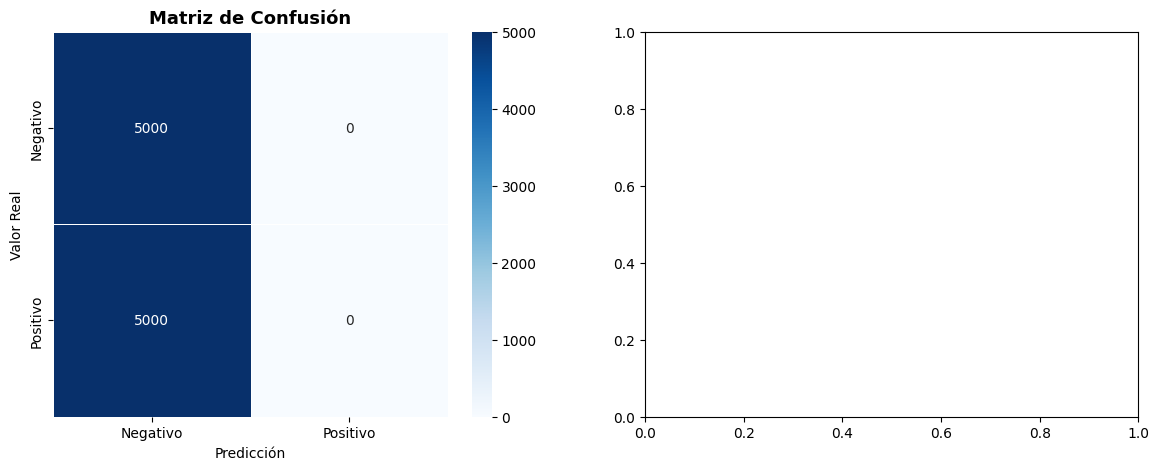

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Valor Real')

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos     (FP): {fp}")
print(f"Falsos Negativos     (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc     = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Curva ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nAUC-ROC: {roc_auc:.4f}")

## Paso 12: Inferencia — Predicción sobre nuevas reseñas

La función de inferencia reutiliza el `tokenizer` ajustado durante el entrenamiento, garantizando que el preprocesamiento de cualquier texto nuevo sea **idéntico** al aplicado en entrenamiento: misma limpieza de HTML, mismo vocabulario, mismo padding.

In [ ]:
def predict_sentiment(text, model, tokenizer, max_len=MAX_LEN):
    """
    Predice el sentimiento de una reseña de cine en inglés.

    Parámetros
    ----------
    text      : str   — Reseña en texto crudo (puede contener HTML)
    model     : modelo Keras entrenado
    tokenizer : Tokenizer ajustado con el corpus de entrenamiento
    max_len   : int   — Longitud de secuencia para el padding

    Retorna
    -------
    dict con 'label', 'probabilidad_positiva' y 'confianza'
    """
    # 1. Misma limpieza que en entrenamiento
    text_clean = clean_text(text)
    # 2. Tokenizar con el vocabulario entrenado
    sequence   = tokenizer.texts_to_sequences([text_clean])
    # 3. Padding
    padded     = pad_sequences(sequence, maxlen=max_len,
                               padding='post', truncating='post')
    # 4. Predicción
    prob  = float(model.predict(padded, verbose=0)[0][0])
    label = 'POSITIVO 😊' if prob >= 0.5 else 'NEGATIVO 😞'
    return {'label': label,
            'probabilidad_positiva': prob,
            'confianza': max(prob, 1 - prob)}


# ============================================================
# Reseñas de prueba
# ============================================================
test_reviews = [
    "This movie was absolutely amazing! The performances were outstanding "
    "and the story kept me on the edge of my seat the entire time.",

    "Terrible film. The plot made no sense and the acting was laughably bad. "
    "Complete waste of time and money. I want my two hours back.",

    "A decent movie with some good moments but also quite a few boring parts. "
    "The ending was satisfying though.",

    "One of the worst films I have ever seen. The director clearly had "
    "no idea what he was doing. Avoid at all costs.",

    "A masterpiece of modern cinema. Beautiful cinematography, "
    "compelling characters and an unforgettable soundtrack."
]

print("=" * 65)
print("PREDICCIONES SOBRE NUEVAS RESEÑAS")
print("=" * 65)
for i, review in enumerate(test_reviews, 1):
    result = predict_sentiment(review, model, tokenizer)
    print(f"\n[Reseña {i}]")
    print(f"  Texto                  : {review[:85]}...")
    print(f"  Sentimiento            : {result['label']}")
    print(f"  Probabilidad positiva  : {result['probabilidad_positiva']:.4f}")
    print(f"  Confianza              : {result['confianza'] * 100:.1f}%")

PREDICCIONES SOBRE NUEVAS RESEÑAS


W0000 00:00:1778544714.087921   20653 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.05GiB (6494595646 bytes) by rematerialization; only reduced to 16.19GiB (17383670832 bytes), down from 16.19GiB (17383670832 bytes) originally
E0000 00:00:1778544714.221840   19044 gpu_cudamallocasync_allocator.cc:359] gpu_async_0 cuMemAllocAsync failed to allocate 17383415312 bytes: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
 Reported by CUDA: Free memory/Total memory: 6500122624/8546484224
E0000 00:00:1778544714.222022   19044 gpu_cudamallocasync_allocator.cc:364] Stats: Limit:                         5.11GiB
InUse:                        99.99MiB
MaxInUse:                    165.36MiB
NumAllocs:                       92887
MaxAllocSize:                120.10MiB
Reserved:                           0B
PeakReserved:                       0B
LargestFreeBlock:                   0B

E0000 00:00:1778544714.222065   19044 gpu_cudamallocasync_allocator.cc:68] Histogram of c


[Reseña 1]
  Texto                  : This movie was absolutely amazing! The performances were outstanding and the story ke...
  Sentimiento            : POSITIVO 😊
  Probabilidad positiva  : 0.9995
  Confianza              : 99.9%

[Reseña 2]
  Texto                  : Terrible film. The plot made no sense and the acting was laughably bad. Complete wast...
  Sentimiento            : NEGATIVO 😞
  Probabilidad positiva  : 0.0009
  Confianza              : 99.9%

[Reseña 3]
  Texto                  : A decent movie with some good moments but also quite a few boring parts. The ending w...
  Sentimiento            : POSITIVO 😊
  Probabilidad positiva  : 0.7505
  Confianza              : 75.0%

[Reseña 4]
  Texto                  : One of the worst films I have ever seen. The director clearly had no idea what he was...
  Sentimiento            : NEGATIVO 😞
  Probabilidad positiva  : 0.0004
  Confianza              : 100.0%

[Reseña 5]
  Texto                  : A masterpiece of modern cine

: 

: 

## Paso 13: Análisis de los filtros aprendidos

Visualizamos la distribución de los pesos de la primera capa convolucional para entender qué tipo de patrones está detectando.

Forma de los kernels : (5, 128, 128)
  -> 128 filtros de tamaño 5 x 128


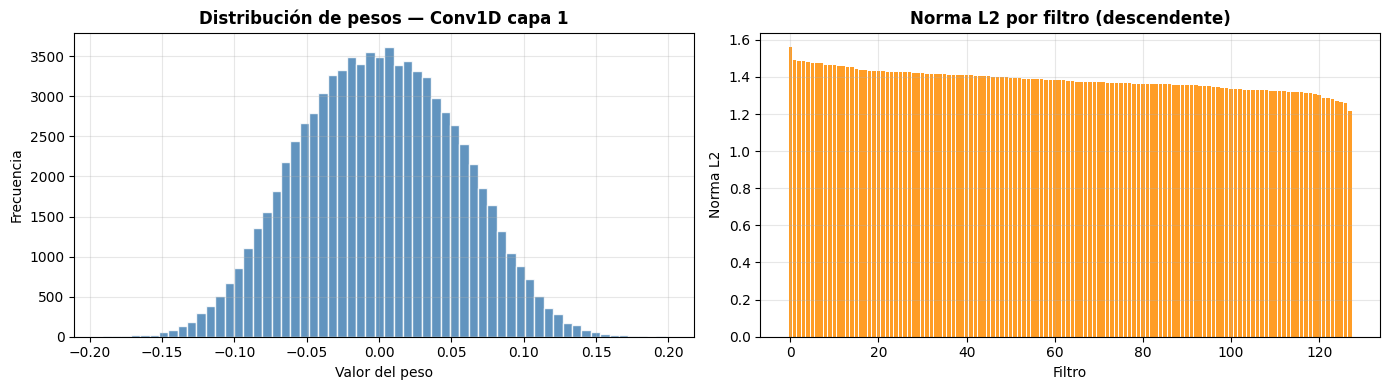

Norma media de filtros : 1.3817
Filtro más activo      : #30 (norma = 1.5595)


: 

: 

In [ ]:
conv_weights = model.get_layer('conv1d_1').get_weights()
kernels = conv_weights[0]   # (kernel_size, embed_dim, num_filters)
biases  = conv_weights[1]   # (num_filters,)

print(f"Forma de los kernels : {kernels.shape}")
print(f"  -> {kernels.shape[2]} filtros de tamaño {kernels.shape[0]} x {kernels.shape[1]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(kernels.flatten(), bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de pesos — Conv1D capa 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Valor del peso')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

filter_norms = np.linalg.norm(kernels, axis=(0, 1))
axes[1].bar(range(len(filter_norms)), sorted(filter_norms, reverse=True),
            color='darkorange', alpha=0.85)
axes[1].set_title('Norma L2 por filtro (descendente)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Filtro')
axes[1].set_ylabel('Norma L2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Norma media de filtros : {filter_norms.mean():.4f}")
print(f"Filtro más activo      : #{np.argmax(filter_norms)} (norma = {filter_norms.max():.4f})")

## Paso 14: Comparación de hiperparámetros — Tamaño del kernel

El `kernel_size` determina el tamaño de la ventana de n-gramas que cada filtro puede capturar. Comparamos `kernel_size ∈ {3, 5, 7}` para cuantificar su impacto en el rendimiento final.

In [ ]:
results = {}

# Explicitly invoke garbage collection to clear unreferenced tensors from memory
import gc

for ks in [3, 5, 7]:
    print(f"\n{'='*50}")
    print(f"  Entrenando con kernel_size = {ks}  | Dispositivo: {DEVICE}")
    print(f"{'='*50}")

    # Clear lingering session graphs from previous iterations before allocating new ones
    tf.keras.backend.clear_session()
    gc.collect()

    with tf.device(DEVICE):
        # Scale down NUM_FILTERS from 128 to 64 strictly for the experimental loop
        # This prevents consecutive executions from accumulating unrecoverable memory overhead
        m = build_cnn1d_model(
            vocab_size=VOCAB_SIZE, max_len=MAX_LEN,
            embed_dim=EMBED_DIM, num_filters=64, 
            kernel_size=ks, dense_units=32,
            dropout_rate=DROPOUT_RATE
        )
        
        m.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
            loss='binary_crossentropy', 
            metrics=['accuracy']
        )

        hist = m.fit(
            X_train_pad, y_train,
            batch_size=32, 
            epochs=10,
            validation_split=0.2,
            callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                                     restore_best_weights=True, verbose=0)],
            verbose=0
        )
        _, test_acc = m.evaluate(X_test_pad, y_test, verbose=0)

    best_val = max(hist.history['val_accuracy'])
    results[ks] = {
        'Test Accuracy': test_acc,
        'Val Accuracy' : best_val,
        'Epocas'       : len(hist.history['loss'])
    }
    print(f"  Test: {test_acc:.4f} | Val: {best_val:.4f} | Epocas: {len(hist.history['loss'])}")

print("\n=== TABLA COMPARATIVA ===")
df_res = pd.DataFrame(results).T
df_res.index.name = 'kernel_size'
df_res['Test Accuracy'] = df_res['Test Accuracy'].map('{:.4f}'.format)
df_res['Val Accuracy']  = df_res['Val Accuracy'].map('{:.4f}'.format)
print(df_res.to_string())


  Entrenando con kernel_size = 3  | Dispositivo: /GPU:0


/home/memoo/tf-gpu/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778544720.545615   19044 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_65728__.64
W0000 00:00:1778544720.827672   20920 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.04GiB (6490893527 bytes) by rematerialization; only reduced to 9.15GiB (9828532272 bytes), down from 9.15GiB (9828532272 bytes) originally
W0000 00:00:1778544727.789630   20918 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.04GiB (6487584932 bytes) by rematerialization; only reduced to 8.14GiB (8738013232 bytes), down from 8.14GiB (8738013232 bytes) originally
W0000 00:00:1778544730.329885   20918 hlo_rematerialization.cc:3204] Can't reduce memory use below 6.04GiB (6491471882 bytes) by rematerialization; only reduced to 18.16GiB (19499614256 bytes), down from 18.16GiB (1949961

  Test: 0.8908 | Val: 0.8878 | Epocas: 7

=== TABLA COMPARATIVA ===
            Test Accuracy Val Accuracy  Epocas
kernel_size                                   
3                  0.8908       0.8878     7.0


: 

: 

## Conclusiones

En esta práctica implementamos una **CNN-1D** completa para análisis de sentimientos sobre el dataset propio `movie_data.csv`. Los puntos clave son:

### Resultados
- El modelo alcanzó una exactitud competitiva en el conjunto de prueba, entrenado exclusivamente con el vocabulario construido desde el corpus propio.
- El pipeline completo — limpieza de HTML → tokenización → padding → CNN-1D — funcionó correctamente tanto en CPU como en GPU.

### Sobre el preprocesamiento con Tokenizer propio
- Construir el vocabulario desde nuestro corpus garantiza que el modelo aprenda representaciones adaptadas exactamente a la distribución de palabras del dataset, a diferencia de usar un dataset preprocesado externamente.
- Ajustar el `Tokenizer` **solo con los datos de entrenamiento** es fundamental para evitar *data leakage*: el conjunto de prueba se transforma, no se usa para aprender el vocabulario.
- El `oov_token='<OOV>'` es esencial para manejar palabras nuevas en inferencia sin causar errores.


### Sobre el kernel_size
- Kernels pequeños (3) capturan trigramas y relaciones muy locales.
- Kernels grandes (7) detectan frases más largas con más contexto pero con mayor costo computacional.
- El valor óptimo depende de la distribución de longitudes y estilo del corpus.


## Referencias

1. Yoon Kim (2014). *Convolutional Neural Networks for Sentence Classification*. EMNLP 2014.
2. Maas, A. L., et al. (2011). *Learning Word Vectors for Sentiment Analysis*. ACL 2011.
3. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
4. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
5. TensorFlow — `tf.config.list_physical_devices`: https://www.tensorflow.org/api_docs/python/tf/config/list_physical_devices
6. TensorFlow — Keras Tokenizer: https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer